In [1]:
from sir.sir_scaled import model as sir_model
import matplotlib.pyplot as plt

from dyMES.model import model
import dyMES.rfunctions as rf
import numpy as np

# SIR

In [2]:
sir_model_obj = sir_model(1.23 / 100, 0.5, 100) # modified: see value of new_c0
sir_model_obj.simulate_sir(99, 1, 0, 14, 0.00001)

In [3]:
scaled_sir_vals = [i * sir_model_obj.G for i in sir_model_obj.sim_n]

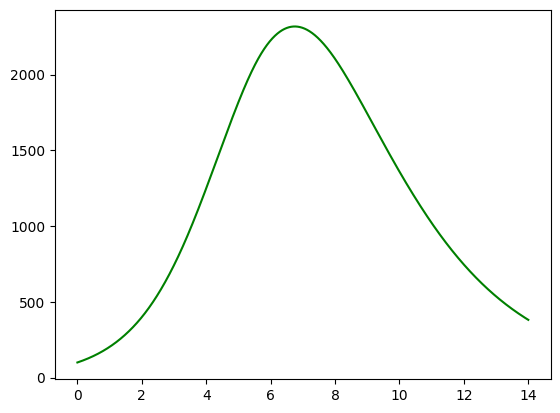

In [4]:
plt.plot(
    sir_model_obj.t,
    [scaled_sir_vals[j] for j in range(len(scaled_sir_vals))],
    label = "New SIR",
    color = 'green',
)

In [5]:
scaled_sir_dead = [r * sir_model_obj.G for r in sir_model_obj.sim_r]

# DyMES infra

In [6]:
def pandemic_func(n, I, params):
    m_effective = (params['m_(t-1)'] - params['c1'] * params['tau'] * params['c0'] * params['m_(t-1)'] * params['<n>_(t-1)'])

    return (params['c0'] * params['h'] * n * np.exp(- 1 * I / params['K'])) * (m_effective - n) - (params['d_0'] * n)

In [7]:
def new_run_model_for_K(K, new_c0 = 0.006, tau = 0.00001, num_days = 7):
    # Instantiate params
    model_params = {
        'm_0': 100,
        'G': 100,
        'K': K,
        'd_0': 0.5,
        'c0': 0.006, # anlogous to r_0. originally 0.006
        'c1': 1,
        'c2': 1,
        'tau': tau,
        '<n>_(t-1)': 0,
        'm_(t-1)': 100, # should be set to the same value as m_0
        'h': 1,
    }
    initial_infected = 100

    pandemic_dymes = model(initial_infected, model_params, pandemic_func, 'G')

    pandemic_dymes.update_param('c0', pandemic_dymes.find_steady_state_params('c0'))
    print("Steady state c0:", pandemic_dymes.params['c0'])

    pandemic_dymes.update_param('c0', new_c0 / model_params['G'])
    print("Updated c0:", pandemic_dymes.params['c0'])
    pandemic_dymes.update(num_days, dt = tau)

    return pandemic_dymes

In [8]:
from dyMES.model_k_inf import model as model_k_inf

In [9]:
def pandemic_func_K_inf(n, I, params):
    m_effective = (params['m_(t-1)'] - params['c1'] * params['tau'] * params['c0'] * params['m_(t-1)'] * params['<n>_(t-1)'])

    return (params['c0'] * params['h'] * n * np.exp(0)) * (m_effective - n) - (params['d_0'] * n)

In [10]:
def new_run_model_for_K_inf(new_c0 = 0.006, tau = 0.00001, num_days = 7):
  # Instantiate params
  model_params = {
    'm_0': 100,
    'G': 100,
    # 'K': K,
    'd_0': 0.5,
    'c0': 0.006, # anlogous to r_0. originally 0.006
    'c1': 1,
    'c2': 1,
    'tau': tau,
    '<n>_(t-1)': 0,
    'm_(t-1)': 100, # should be set to the same value as m_0
    'h': 1,
  }
  initial_infected = 100

  pandemic_dymes = model_k_inf(initial_infected, model_params, pandemic_func_K_inf, 'G')

  pandemic_dymes.update_param('c0', pandemic_dymes.find_steady_state_params('c0'))
  print("Steady state c0:", pandemic_dymes.params['c0'])

  pandemic_dymes.update_param('c0', new_c0 / model_params['G'])
  print("Updated c0:", pandemic_dymes.params['c0'])
  pandemic_dymes.update(num_days, dt = tau)

  return pandemic_dymes

# Test DyMES

# K = 100

In [11]:
non_dec_c0_K_100 = new_run_model_for_K(100, new_c0 = 1.23, num_days = 14)

Steady state c0: 0.014011764026381998
Updated c0: 0.0123
1e-05
Error: 4.232447189667272e-18
0.9999993891484832 [0.69314718 0.        ] 0.9999993891484832 1.9999993891484529
Determinant: 51174.85123420797
Determinant: 51143.27610122423
Determinant: 51111.89102556965
Determinant: 51080.69485123841
Determinant: 51049.68643033695
Determinant: 51018.86462301688
Determinant: 50988.228297412614
Determinant: 50957.77632957446
Determinant: 50927.50760340576
Determinant: 50897.421010600716
0.09999999999999393
Error: 4.1092585036727845e-10
0.9940167874537476 [6.96151980e-01 1.61146006e-08] 0.9940167874537476 1.9940167871646683
Determinant: 50867.51545057931
Determinant: 50837.789830426926
Determinant: 50808.24306483233
Determinant: 50778.87407602667
Determinant: 50749.68179372239
Determinant: 50720.66515505448
Determinant: 48301.1286315708
Determinant: 48273.31664282821
Determinant: 48245.67181352637
Determinant: 48218.19314007457
0.20000000000005924
Error: 1.6032911828920726e-09
0.98827515384406

In [12]:
non_dec_c0_K_100.states[7 * (10 ** 5) - 1]

np.float64(82.47460045228851)

In [13]:
non_dec_c0_K_100.states[-1]

np.float64(75.19554829442147)

In [14]:
non_dec_c0_K_100.num_dead[-1]

np.float64(586.3548659198391)

In [15]:
non_dec_c0_K_100.num_dead[7 * (10 ** 5) - 1]

np.float64(310.9546210196778)

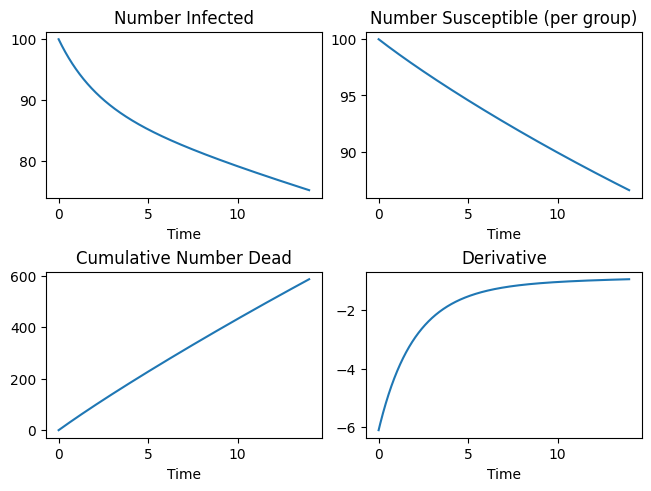

In [16]:
non_dec_c0_K_100.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.         0.4870838  0.23725063 0.11556094 0.05628786 0.02741691
 0.01335433 0.00650468 0.00316832 0.00154324]
[1.         0.47768721 0.22818507 0.10900109 0.05206843 0.02487242
 0.01188124 0.00567552 0.00271112 0.00129507]
[1.         0.47053001 0.22139849 0.10417463 0.04901729 0.02306411
 0.01085235 0.00510636 0.00240269 0.00113054]
[1.         0.46480471 0.21604342 0.100418   0.04667476 0.02169465
 0.01008377 0.00468699 0.00217853 0.00101259]
[1.00000000e+00 4.60000716e-01 2.11600660e-01 9.73364559e-02
 4.47748399e-02 2.05964588e-02 9.47438596e-03 4.35822442e-03
 2.00478641e-03 9.22203212e-04]
[1.00000000e+00 4.55793515e-01 2.07747729e-01 9.46900685e-02
 4.31591197e-02 1.96716472e-02 8.96620940e-03 4.08674020e-03
 1.86270973e-03 8.49011044e-04]
[1.00000000e+00 4.51975673e-01 2.04282010e-01 9.23304999e-02
 4.17311404e-02 1.88614606e-02 8.52492154e-03 3.85305725e-03
 1.74148

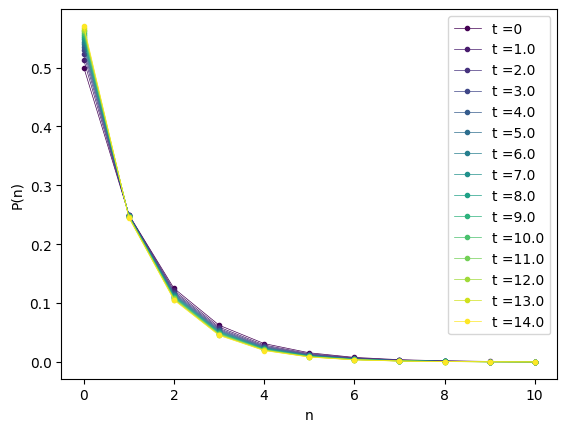

In [17]:
non_dec_c0_K_100.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = 200

In [18]:
non_dec_c0_K_200 = new_run_model_for_K(200, new_c0 = 1.23, num_days = 14)

Steady state c0: 0.0084985639956253
Updated c0: 0.0123
1e-05
Error: 8.073528995794096e-17
1.0000022366062362 [0.69314718 0.        ] 1.0000022366062362 2.000002236605556
Determinant: 41113.56861893216
Determinant: 41252.76684495086
Determinant: 41391.98499090455
Determinant: 41531.220666079476
Determinant: 41670.47148608246
Determinant: 41809.73507300216
Determinant: 41949.00905556732
Determinant: 42088.29106930422
Determinant: 42227.57875669147
Determinant: 42366.869767313234
0.09999999999999393
Error: 8.581450476184195e-09
1.022144911332205 [6.82256528e-01 2.20458956e-07] 1.022144911332205 2.0221449044585724
Determinant: 42506.16175801083
Determinant: 42645.452393032545
Determinant: 42784.73934417968
Determinant: 42924.020290952576
Determinant: 43063.292920694665
Determinant: 43202.554928732294
Determinant: 43341.80401851707
Determinant: 43481.03790176022
Determinant: 43620.25429857009
Determinant: 43759.450937585105
0.20000000000005924
Error: 3.358812176961008e-08
1.0438319932388562

In [19]:
non_dec_c0_K_200.states[7 * (10 ** 5) - 1]

np.float64(150.6607045231262)

In [20]:
non_dec_c0_K_200.states[-1]

np.float64(131.63396897778966)

In [21]:
non_dec_c0_K_200.num_dead[7 * (10 ** 5) - 1]

np.float64(488.4340694939335)

In [22]:
non_dec_c0_K_200.num_dead[-1]

np.float64(985.2257025055882)

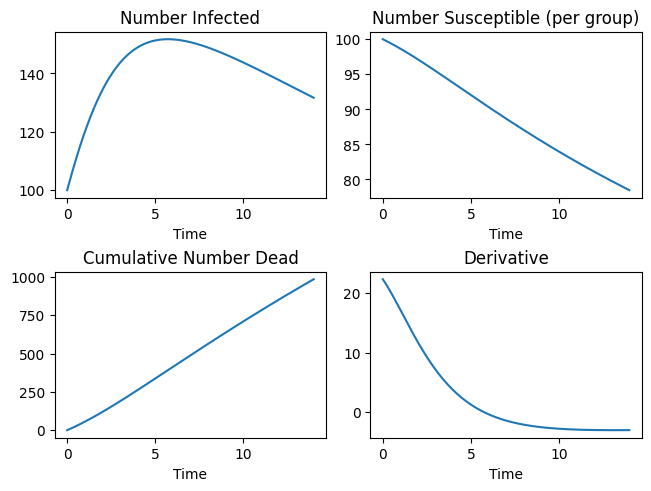

In [23]:
non_dec_c0_K_200.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.         0.54521228 0.29725643 0.16206786 0.0883614  0.04817572
 0.026266   0.01432055 0.00780774 0.00425688]
[1.         0.57318177 0.32853735 0.18831163 0.10793681 0.06186742
 0.03546128 0.02032576 0.01165036 0.00667778]
[1.         0.58949896 0.34750903 0.20485623 0.12076254 0.0711894
 0.04196609 0.02473897 0.0145836  0.00859702]
[1.         0.59821667 0.3578632  0.21407975 0.12806609 0.07661128
 0.04583015 0.02741637 0.01640093 0.00981131]
[1.         0.60200844 0.36241417 0.2181764  0.13134405 0.07907023
 0.04760095 0.02865618 0.01725127 0.01038541]
[1.         0.60258964 0.36311428 0.21880892 0.131852   0.07945266
 0.04787736 0.0288504  0.01738496 0.010476  ]
[1.         0.60105789 0.3612706  0.21714456 0.13051646 0.07844796
 0.04715177 0.02834095 0.01703456 0.01023876]
[1.         0.59812005 0.35774761 0.21397603 0.12798337 0.07654943
 0.04578575 0.02738538 0.01637975

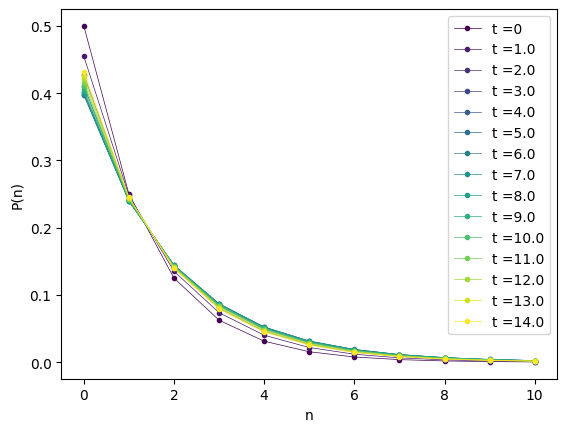

In [24]:
non_dec_c0_K_200.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = 400

In [25]:
non_dec_c0_K_400 = new_run_model_for_K(400, new_c0 = 1.23, num_days = 14)

Steady state c0: 0.006618688166504162
Updated c0: 0.0123
1e-05
Error: 1.446706457072303e-16
1.0000042919912437 [0.69314718 0.        ] 1.0000042919912437 2.0000042919874295
Determinant: 35546.568797637075
Determinant: 35740.29612239695
Determinant: 35934.773257648405
Determinant: 36129.999876562804
Determinant: 36325.97561488034
Determinant: 36522.70007073717
Determinant: 36720.17280449783
Determinant: 36918.39333859071
Determinant: 37117.36115735178
Determinant: 37317.07570687009
0.09999999999999393
Error: 1.849542470024415e-08
1.0432286948053708 [6.72212480e-01 9.91926133e-07] 1.0432286948053708 2.04322865299666
Determinant: 37517.53639484041
Determinant: 37718.74259042097
Determinant: 37920.69362409593
Determinant: 38123.388787545315
Determinant: 38326.82733351646
Determinant: 38531.008475705385
Determinant: 38735.9313886397
Determinant: 38941.59520757091
Determinant: 39147.99902836945
Determinant: 39355.14190742688
0.20000000000005924
Error: 7.311050714870997e-08
1.0870190226595648

In [26]:
non_dec_c0_K_400.states[7 * (10 ** 5) - 1]

np.float64(261.95438127825673)

In [27]:
non_dec_c0_K_400.states[-1]

np.float64(208.49313252943708)

In [28]:
non_dec_c0_K_400.num_dead[7 * (10 ** 5) - 1]

np.float64(749.8423413444679)

In [29]:
non_dec_c0_K_400.num_dead[-1]

np.float64(1584.7820755184446)

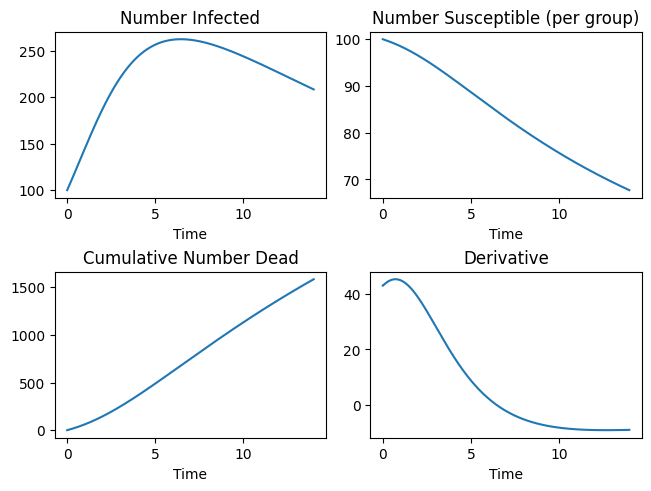

In [30]:
non_dec_c0_K_400.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.         0.59130546 0.34964221 0.20674541 0.12224975 0.07228699
 0.04274373 0.02527462 0.01494504 0.00883709]
[1.         0.6516594  0.42466008 0.27673387 0.18033636 0.117518
 0.0765818  0.04990533 0.03252133 0.02119287]
[1.         0.68824634 0.47368315 0.32601088 0.22437598 0.15442612
 0.10628336 0.07314926 0.05034481 0.03464971]
[1.         0.70900561 0.5026891  0.35640959 0.25269662 0.17916352
 0.12702812 0.09006381 0.06385587 0.04527427]
[1.         0.71965323 0.51790092 0.37270928 0.26822166 0.1930268
 0.13891255 0.09996903 0.07194318 0.05177426]
[1.         0.72381529 0.52390872 0.37921335 0.27448064 0.1986735
 0.14380312 0.10408706 0.07533995 0.05453233]
[1.         0.72372547 0.5237787  0.37907219 0.27434442 0.19855026
 0.14369608 0.10399668 0.07526519 0.05447146]
[1.         0.72077012 0.51950972 0.37444729 0.26989065 0.19452933
 0.14021113 0.10106016 0.07284129 0.

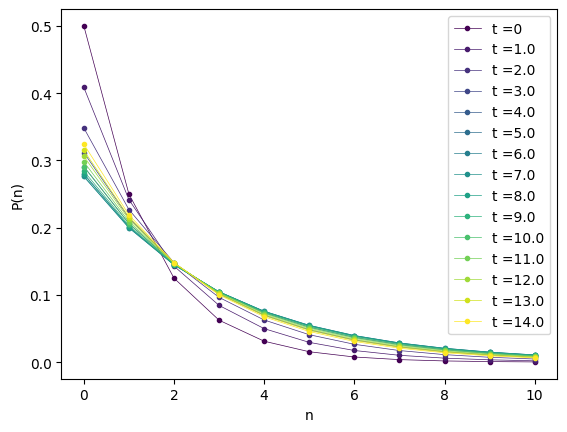

In [31]:
non_dec_c0_K_400.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = 50

In [32]:
non_dec_c0_K_50 = new_run_model_for_K(50, new_c0 = 1.23, num_days = 14)

Steady state c0: 0.038087932991298604
Updated c0: 0.0123
1e-05
Error: 1.9614005833648095e-17
0.9999966146407718 [0.69314718 0.        ] 0.9999966146407718 1.9999966146405486
Determinant: 68830.99662903261
Determinant: 68525.23876627469
Determinant: 65811.83245279813
Determinant: 65518.30036942806
Determinant: 65226.83258318575
Determinant: 64937.4163356342
Determinant: 62335.80208124471
Determinant: 62058.08215294042
Determinant: 61782.323763374814
Determinant: 59279.581897467164
0.09999999999999393
Error: 1.3102824635241643e-09
0.9672369372334626 [7.09940223e-01 3.31888043e-07] 0.9672369372334626 1.9672369350619539
Determinant: 59015.08346587505
Determinant: 58752.45963109629
Determinant: 56345.80056639107
Determinant: 56094.01273304458
Determinant: 55844.01553288423
Determinant: 53530.69824311196
Determinant: 53291.125198416514
Determinant: 53053.26172504497
Determinant: 50830.59337027773
Determinant: 50602.75403828056
0.20000000000005924
Error: 6.55556342978925e-09
0.936560069956809

In [33]:
non_dec_c0_K_50.states[7 * (10 ** 5) - 1]

np.float64(43.97485440650665)

In [34]:
non_dec_c0_K_50.states[-1]

np.float64(40.4590263323514)

In [35]:
non_dec_c0_K_50.num_dead[7 * (10 ** 5) - 1]

np.float64(201.39276451378177)

In [36]:
non_dec_c0_K_50.num_dead[-1]

np.float64(347.8109379486151)

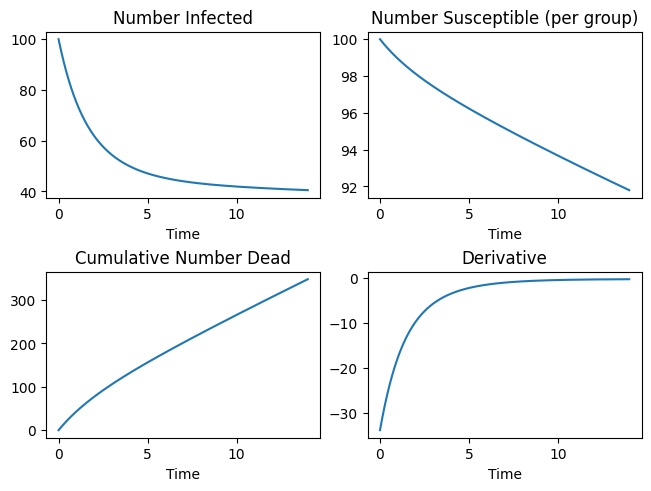

In [37]:
non_dec_c0_K_50.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.00000000e+00 4.29014169e-01 1.84053160e-01 7.89614166e-02
 3.38755684e-02 1.45330999e-02 6.23490638e-03 2.67486348e-03
 1.14755449e-03 4.92317209e-04]
[1.00000000e+00 3.82142210e-01 1.46032676e-01 5.58052551e-02
 2.13255467e-02 8.14939314e-03 3.11422787e-03 1.19007827e-03
 4.54779298e-04 1.73790435e-04]
[1.00000000e+00 3.52110066e-01 1.23981508e-01 4.36551442e-02
 1.53714194e-02 5.41243325e-03 1.90577300e-03 6.71042182e-04
 2.36280841e-04 8.31969163e-05]
[1.00000000e+00 3.32745311e-01 1.10719454e-01 3.68413870e-02
 1.22588027e-02 4.07906088e-03 1.35728911e-03 4.51631878e-04
 1.50278503e-04 5.00045101e-05]
[1.00000000e+00 3.20001888e-01 1.02401221e-01 3.27685925e-02
 1.04860155e-02 3.35554646e-03 1.07378188e-03 3.43612492e-04
 1.09956744e-04 3.51864015e-05]
[1.00000000e+00 3.11387261e-01 9.69620398e-02 3.01927525e-02
 9.40164245e-03 2.92755333e-03 9.11603454e-04 2.83861942e-0

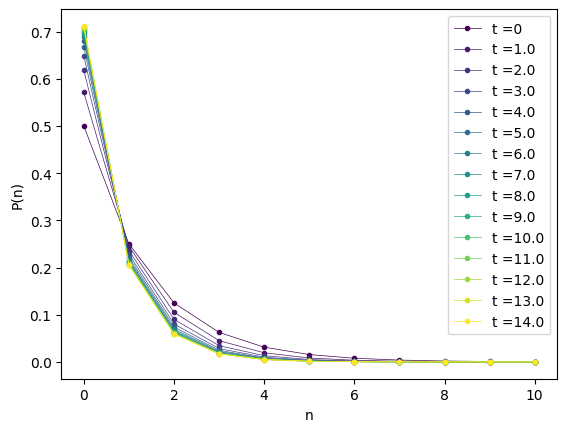

In [38]:
non_dec_c0_K_50.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = 25

In [39]:
non_dec_c0_K_25 = new_run_model_for_K(25, new_c0 = 1.23, num_days = 14)

Steady state c0: 0.281434579608193
Updated c0: 0.0123
1e-05
Error: 2.564686464202883e-18
0.9999952185078451 [0.69314718 0.        ] 0.9999952185078451 1.9999952185077938
Determinant: 79809.13144756044
Determinant: 79394.68054716646
Determinant: 76569.04989799549
Determinant: 76170.16265109998
Determinant: 73433.27174528065
Determinant: 73049.46399228394
Determinant: 70399.20888616196
Determinant: 70030.01015952587
Determinant: 67464.32778490952
Determinant: 67109.28092215217
0.09999999999999393
Error: 1.2647467766357262e-12
0.9535179833935624 [7.17226685e-01 5.79858492e-07] 0.9535179833935624 1.9535179828346465
Determinant: 64626.148089484785
Determinant: 64284.808851999136
Determinant: 63945.148711553724
Determinant: 61554.17797373096
Determinant: 61227.72811865278
Determinant: 58915.02244480671
Determinant: 58601.365776499406
Determinant: 56365.02526528216
Determinant: 56063.75642069458
Determinant: 53901.91701898899
0.20000000000005924
Error: 1.1149368179109515e-10
0.909628188563308

In [40]:
non_dec_c0_K_25.states[7 * (10 ** 5) - 1]

np.float64(23.30914008546261)

In [41]:
non_dec_c0_K_25.states[-1]

np.float64(21.04506765804587)

In [42]:
non_dec_c0_K_25.num_dead[7 * (10 ** 5) - 1]

np.float64(140.7259420195386)

In [43]:
non_dec_c0_K_25.num_dead[-1]

np.float64(216.9296977422482)

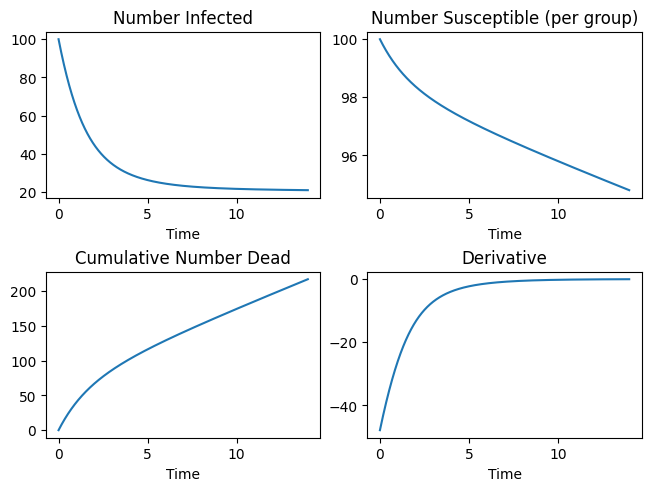

In [44]:
non_dec_c0_K_25.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.00000000e+00 3.89936242e-01 1.52050275e-01 5.92899144e-02
 2.31192874e-02 9.01504856e-03 3.51529441e-03 1.37074081e-03
 5.34501574e-04 2.08421559e-04]
[1.00000000e+00 3.09296733e-01 9.56644769e-02 2.95887150e-02
 9.15169513e-03 2.83059033e-03 8.75492700e-04 2.70787165e-04
 8.37536334e-05 2.59047421e-05]
[1.00000000e+00 2.58142935e-01 6.66377899e-02 1.72020824e-02
 4.44059901e-03 1.14631029e-03 2.95912233e-04 7.63877549e-05
 1.97189901e-05 5.09032709e-06]
[1.00000000e+00 2.27098472e-01 5.15737377e-02 1.17123268e-02
 2.65985487e-03 6.04049988e-04 1.37179116e-04 3.11532459e-05
 7.07487527e-06 1.60669874e-06]
[1.00000000e+00 2.08108255e-01 4.33090728e-02 9.01298679e-03
 1.87568045e-03 3.90345557e-04 8.12343853e-05 1.69056092e-05
 3.51821215e-06 7.32172633e-07]
[1.00000000e+00 1.96206268e-01 3.84969302e-02 7.55335105e-03
 1.48201837e-03 2.90782221e-04 5.70535219e-05 1.11943122e-0

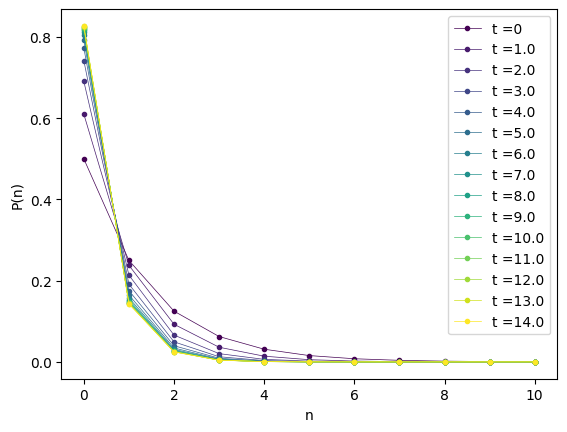

In [45]:
non_dec_c0_K_25.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = 10

In [46]:
non_dec_c0_K_10 = new_run_model_for_K(10, new_c0 = 1.23, tau = 0.00001, num_days = 14)

Steady state c0: 113.67169227864795
Updated c0: 0.0123
1e-05
Error: 1.3690852048281557e-18
0.9999950005299657 [0.69314718 0.        ] 0.9999950005299657 1.9999950005299658
Determinant: 81672.09793844636
Determinant: 81264.96970967045
Determinant: 78446.04550245652
Determinant: 78054.97442272065
Determinant: 75324.06039551855
Determinant: 74948.5270888257
Determinant: 72303.43093894074
Determinant: 71942.92953758991
Determinant: 69381.50347317145
Determinant: 69035.5413324814
0.09999999999999393
Error: 5.7810119759735513e-11
0.9512357945864959 [7.18453965e-01 6.23192395e-07] 0.9512357945864959 1.9512357945844945
Determinant: 66555.68129204033
Determinant: 66223.7787106144
Determinant: 63823.4235948035
Determinant: 63505.11354023365
Determinant: 61182.24445655143
Determinant: 60877.07229645393
Determinant: 58629.71181525581
Determinant: 58337.23505354021
Determinant: 56163.44647691875
Determinant: 55883.2344951803
0.20000000000005924
Error: 6.4678649972804385e-12
0.904853259511428 [7.443

/Users/meilinyen/Desktop/dymes_052026/dyMES/rfunctions.py:37: RuntimeWarning: overflow encountered in exp
  return np.exp(-1 * lambdas[0] * n_array - lambdas[1] * transition_function(n_array, N, params))
/Users/meilinyen/Desktop/dymes_052026/dyMES/model.py:352: RuntimeWarning: invalid value encountered in scalar divide
  n_mean = rf.Rn_mean(self.func, self.states[-1], m_effective, self.params, lambdas)/Z
/Users/meilinyen/Desktop/dymes_052026/dyMES/model.py:353: RuntimeWarning: invalid value encountered in scalar divide
  f_mean = rf.R_mean(self.func, self.states[-1],  m_effective, self.params, lambdas, mean_func=lambda n: self.func(n, self.states[-1], self.params))/Z
/Users/meilinyen/Desktop/dymes_052026/dyMES/model.py:372: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  new_lambdas = fsolve(constraints, starting_point)
/Users/meilinyen/Desktop/dymes_052026/dyMES/rfunctions.py:11: RuntimeWarning: overflow encou

8.399999999851163
Error: 1.045244425398397
0.08584827274580815 [2.53753671e+00 9.71256869e-04] 0.08584827274580815 1.0858482705807666
Determinant: 0.0494799336414212
Determinant: 0.048857589275813136
Determinant: 0.04823449219974776
Determinant: 0.04761915670295149
Determinant: 0.04700318532135732
Determinant: 0.0463947807207476
Determinant: 0.045785854026592285
Determinant: 0.045184303107254714
Determinant: 0.04458234091495371
Determinant: 0.04398756721563348
8.49965999984739
Error: 0.9644532249174094
0.08584836091021197 [2.53753572e+00 9.71256869e-04] 0.08584836091021197 1.085848358736424
8.499999999847377
Error: 0.9641882231251907
0.08584836121127401 [2.53753571e+00 9.71256869e-04] 0.08584836121127401 1.0858483590374568
Determinant: 0.043392490155772526
Determinant: 0.042804417964691956
Determinant: 0.04221614747868409
Determinant: 0.04163470182931461
Determinant: 0.041053160164052645
Determinant: 0.04047826683085229
Determinant: 0.039903377033268475
Determinant: 0.03933496252733515

In [47]:
non_dec_c0_K_10.states[7 * (10 ** 5) - 1]

np.float64(10.451278996415443)

In [48]:
non_dec_c0_K_10.states[-1]

np.float64(8.651468966320635)

In [49]:
non_dec_c0_K_10.num_dead[7 * (10 ** 5) - 1]

np.float64(107.72651752106826)

In [50]:
non_dec_c0_K_10.num_dead[-1]

np.float64(139.83372604222168)

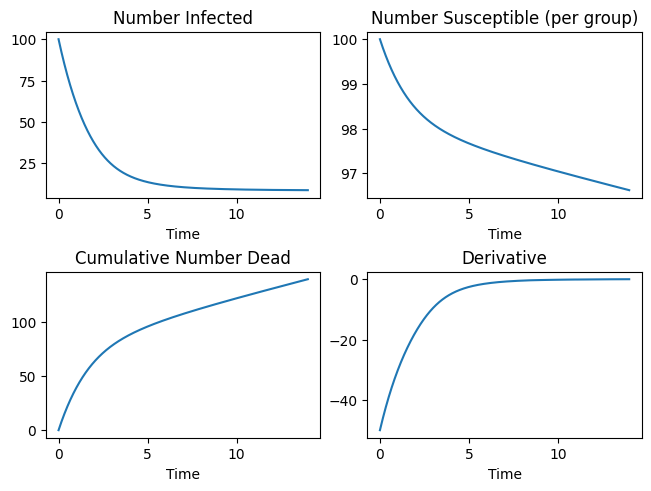

In [51]:
non_dec_c0_K_10.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.00000000e+00 3.77723259e-01 1.42674860e-01 5.38916133e-02
 2.03561158e-02 7.68897843e-03 2.90430600e-03 1.09702393e-03
 4.14371456e-04 1.56517737e-04]
[1.00000000e+00 2.71479120e-01 7.37009140e-02 2.00082600e-02
 5.43182509e-03 1.47462720e-03 4.00330529e-04 1.08681391e-04
 2.95047319e-05 8.00991976e-06]
[1.00000000e+00 1.94030345e-01 3.76477809e-02 7.30481424e-03
 1.41735630e-03 2.75010306e-04 5.33603868e-05 1.03535441e-05
 2.00890395e-06 3.89788820e-07]
[1.00000000e+00 1.46139140e-01 2.13566626e-02 3.12104848e-03
 4.56108255e-04 6.66554464e-05 9.74100215e-06 1.42354738e-06
 2.08036963e-07 3.04025054e-08]
[1.00000000e+00 1.18504890e-01 1.40434335e-02 1.66422137e-03
 1.97219407e-04 2.33716279e-05 2.76967646e-06 3.28223656e-07
 3.88965854e-08 4.60950020e-09]
[1.00000000e+00 1.02127482e-01 1.04300582e-02 1.06520285e-03
 1.08787599e-04 1.11103553e-05 1.13469197e-06 1.15885607e-0

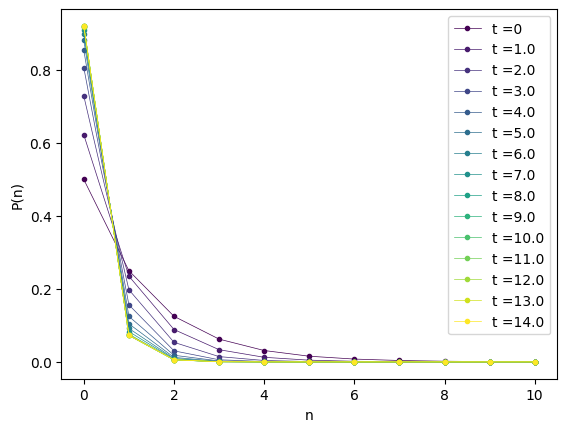

In [52]:
non_dec_c0_K_10.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = inf

In [53]:
non_dec_c0_K_inf = new_run_model_for_K_inf(tau = 0.00001, new_c0 = 1.23, num_days = 14)

Steady state c0: 0.005154639449178431
Updated c0: 0.0123
1e-05
Error: 1.5237055465072202e-16
1.0000069308750485 [0.69314718 0.        ] 1.0000069308750485 2.000006930861031
Determinant: 32771.82542940427
Determinant: 33020.02806199084
Determinant: 33270.147123375085
Determinant: 33522.19789446697
Determinant: 33776.19578360816
Determinant: 34032.15632768164
Determinant: 34290.09519322381
Determinant: 34550.02817755176
Determinant: 34811.971209896314
Determinant: 35075.94035254731
0.09999999999999393
Error: 1.3575973091238687e-08
1.0715901803738712 [6.59174177e-01 2.97413829e-06] 1.0715901803738712 2.0715900063122636
Determinant: 35341.95180200603
Determinant: 35610.02189014767
Determinant: 35880.16708539454
Determinant: 36152.40399389989
Determinant: 36426.7493607378
Determinant: 36703.22007110716
Determinant: 36981.83315154174
Determinant: 37262.60577113434
Determinant: 37545.55524276684
Determinant: 37830.69902435232
0.20000000000005924
Error: 1.0428635831242449e-07
1.147909906273542

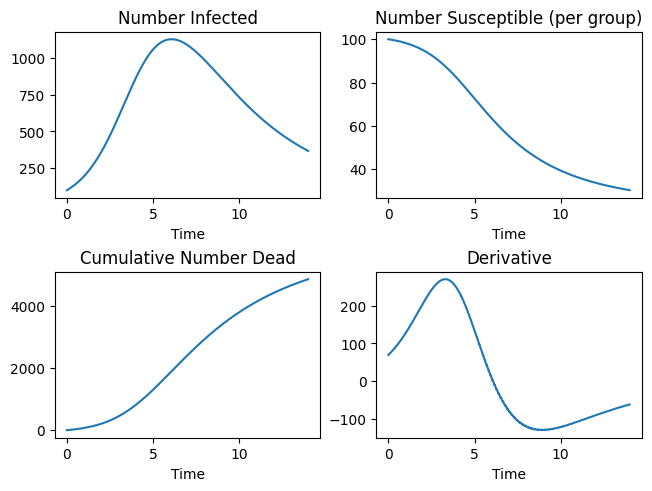

In [54]:
non_dec_c0_K_inf.graph_v2()

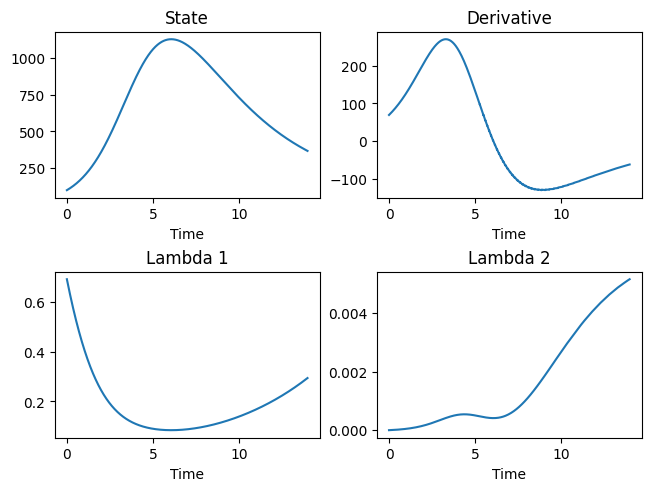

In [55]:
non_dec_c0_K_inf.graph()

In [56]:
non_dec_c0_K_inf.params

{'m_0': 100,
 'G': 100,
 'd_0': 0.5,
 'c0': 0.0123,
 'c1': 1,
 'c2': 1,
 'tau': 1e-05,
 '<n>_(t-1)': np.float64(3.674695117621947),
 'm_(t-1)': np.float64(30.367003515563432),
 'h': 1,
 'I_(t-1)': np.float64(367.4701304163983)}

In [57]:
non_dec_c0_K_inf.lambdas[-1]

array([0.29445549, 0.00514812])

In [58]:
m_effective = non_dec_c0_K_inf.params['m_(t-1)'] - (
    non_dec_c0_K_inf.params['tau'] * 
    non_dec_c0_K_inf.params['c1'] * 
    non_dec_c0_K_inf.params['c0'] * 
    non_dec_c0_K_inf.params['m_(t-1)'] * 
    non_dec_c0_K_inf.params['<n>_(t-1)'])
Z = rf.R_mean(non_dec_c0_K_inf.func, non_dec_c0_K_inf.states[-1], m_effective, non_dec_c0_K_inf.params, non_dec_c0_K_inf.lambdas[-1])

In [59]:
m_effective, Z

(np.float64(30.366989790057445), np.float64(3.9327392454321584))

In [60]:
n_mean = rf.Rn_mean(non_dec_c0_K_inf.func, non_dec_c0_K_inf.states[-1], m_effective, non_dec_c0_K_inf.params, non_dec_c0_K_inf.lambdas[-1])/Z

In [61]:
n_mean

np.float64(2.9345425795400892)

In [62]:
non_dec_c0_K_inf.states[-1]

np.float64(367.4695117621947)

In [63]:
n_mean * non_dec_c0_K_inf.params['G']

np.float64(293.45425795400894)

In [64]:
(non_dec_c0_K_inf.states[-1] - n_mean * non_dec_c0_K_inf.params['G']) ** 2

np.float64(5478.257796290159)

In [65]:
# It's not lambdas being weird it's just straight up not being constrained

# Graphing stuff

In [66]:
list_of_models = [non_dec_c0_K_10,
                  non_dec_c0_K_25,
                  non_dec_c0_K_50,
                  non_dec_c0_K_100,
                  non_dec_c0_K_200,
                  non_dec_c0_K_400,
                  non_dec_c0_K_inf,]
labels = ["K = 10", "K = 25", "K = 50", "K = 100", "K = 200", "K = 400", "K = inf"]
K_vals = [10, 25, 50, 100, 200, 400]

K_cmap = plt.get_cmap('plasma')
K_norm = plt.Normalize(vmin=0, vmax=len(list_of_models))

/Users/meilinyen/Desktop/dymes_052026/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


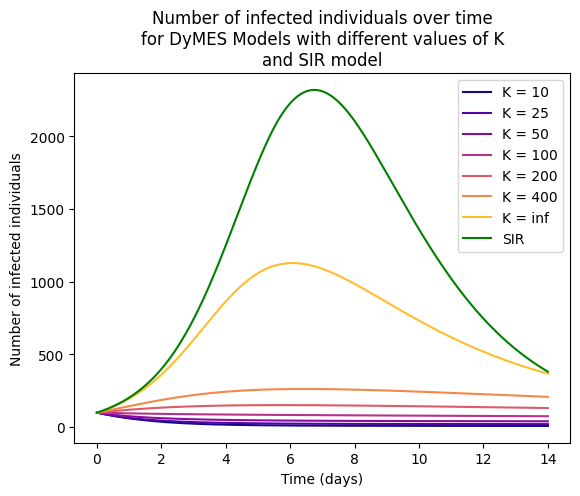

In [67]:
for i in range(len(list_of_models)):
  plt.plot(list_of_models[i].time,
           [list_of_models[i].states[j] for j in range(len(list_of_models[i].states))],
           label = labels[i],
           color = K_cmap(K_norm(i))
  )

plt.plot(
    sir_model_obj.t,
    [scaled_sir_vals[j] for j in range(len(scaled_sir_vals))],
    label = "SIR",
    color = 'green',
)

# plt.yscale('log')
plt.xlabel("Time (days)")
plt.ylabel("Number of infected individuals")
plt.title("Number of infected individuals over time\nfor DyMES Models with different values of K\nand SIR model")
plt.legend()
plt.show()
plt.show()

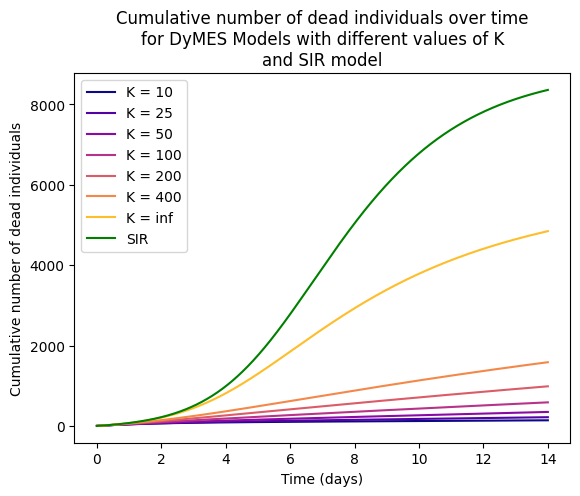

In [68]:
for i in range(len(list_of_models)):
  plt.plot(list_of_models[i].time,
           [list_of_models[i].num_dead[j] for j in range(len(list_of_models[i].num_dead))],
           label = labels[i],
           color = K_cmap(K_norm(i))
  )

plt.plot(
    sir_model_obj.t,
    [scaled_sir_dead[j] for j in range(len(scaled_sir_dead))],
    label = "SIR",
    color = 'green',
)

# plt.yscale('log')
plt.xlabel("Time (days)")
plt.ylabel("Cumulative number of dead individuals")
plt.title("Cumulative number of dead individuals over time\nfor DyMES Models with different values of K\nand SIR model")
plt.legend()
plt.show()

In [69]:
x_upper_bound = 10

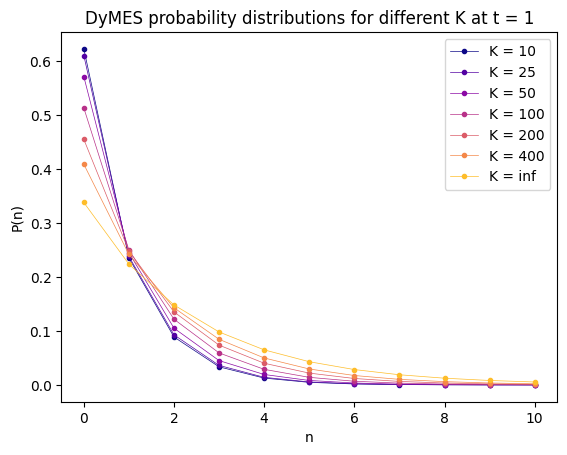

In [70]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[1.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           normalized_pd[0:x_upper_bound+1],
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("P(n)")
plt.title("DyMES probability distributions for different K at t = 1")
plt.legend()
plt.show()

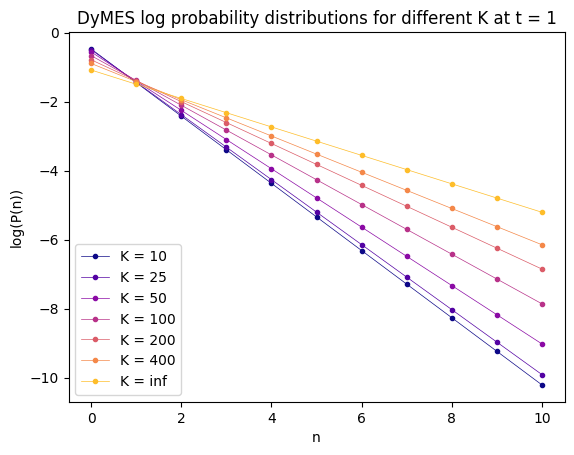

In [71]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[1.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           np.log(normalized_pd[0:x_upper_bound+1]),
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("log(P(n))")
plt.title("DyMES log probability distributions for different K at t = 1")
plt.legend()
plt.show()

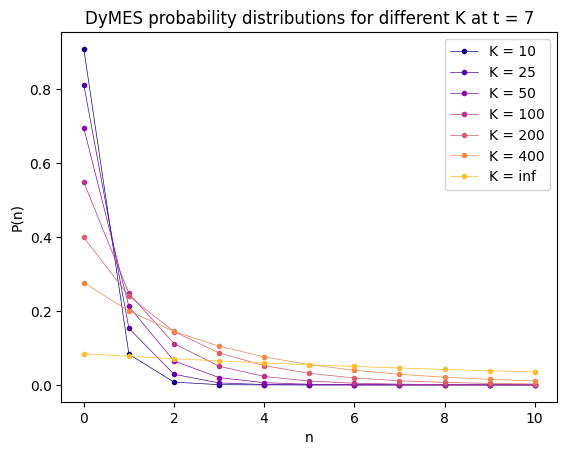

In [72]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[7.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           normalized_pd[0:x_upper_bound+1],
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("P(n)")
plt.title("DyMES probability distributions for different K at t = 7")
plt.legend()
plt.show()

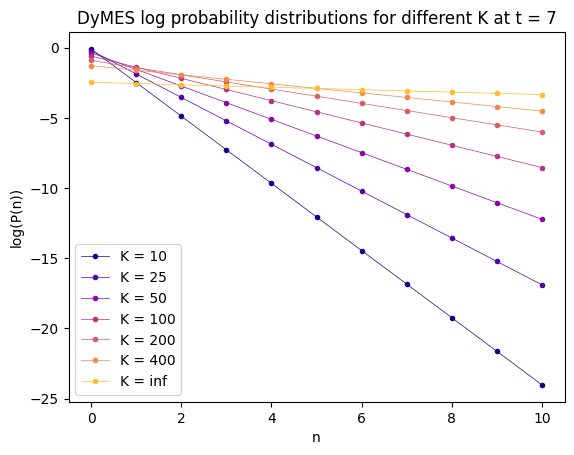

In [73]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[7.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           np.log(normalized_pd[0:x_upper_bound+1]),
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("log(P(n))")
plt.title("DyMES log probability distributions for different K at t = 7")
plt.legend()
plt.show()

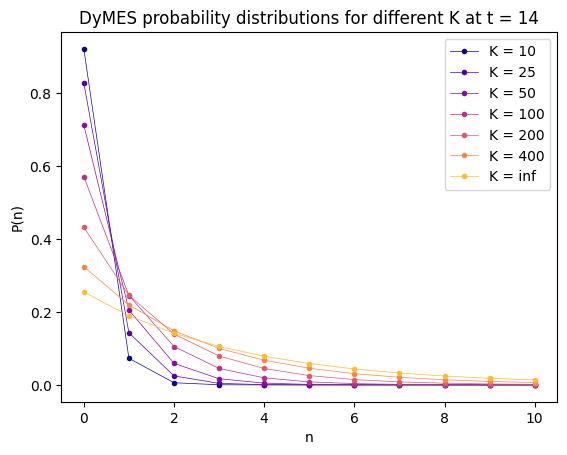

In [74]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[14.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           normalized_pd[0:x_upper_bound+1],
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("P(n)")
plt.title("DyMES probability distributions for different K at t = 14")
plt.legend()
plt.show()

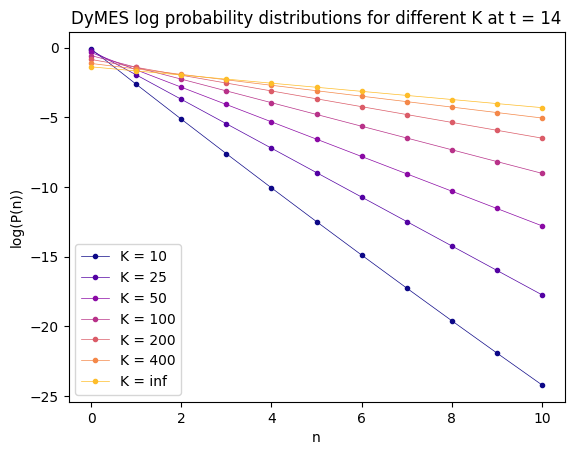

In [75]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[14.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           np.log(normalized_pd[0:x_upper_bound+1]),
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("log(P(n))")
plt.title("DyMES log probability distributions for different K at t = 14")
plt.legend()
plt.show()

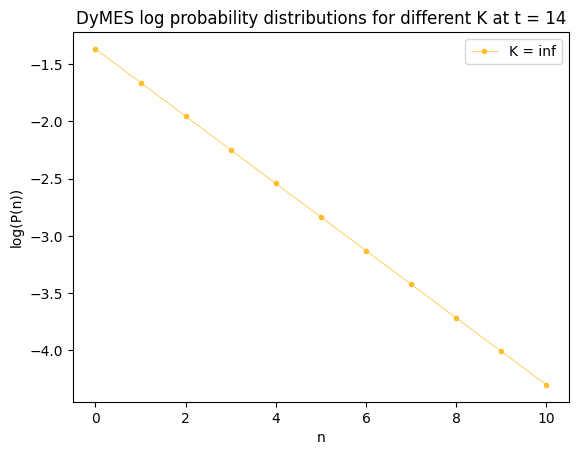

In [76]:
for i in range(len(list_of_models)-1, len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[14.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           np.log(normalized_pd[0:x_upper_bound+1]),
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("log(P(n))")
plt.title("DyMES log probability distributions for different K at t = 14")
plt.legend()
plt.show()